# [LAB11] 지도학습 > 시계열 분석 > Prophet (하이퍼파라미터 튜닝)

## #01. 준비작업

### [1] 패키지 참조

In [1]:
from hossam import *

from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from pandas import to_datetime, DataFrame, DatetimeIndex, Series, date_range, concat
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import holidays

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid

# 로딩바
from tqdm.auto import tqdm

### [2] 데이터셋 가져오기

2020년 2월 5일부터 2023년 5월 31일까지 서울의 Covid19 일일 확진자 수를 기록한 데이터 (출처: 서울시)

In [2]:
origin = load_data("covid19_seoul_230531")
origin.head()

2020년 2월 5일부터 2023년 5월 31일까지 서울의 Covid19 일일 확진자 수를 기록한 데이터 (출처: 서울시)


,서울시 기준일,서울시 확진자,서울시 추가 확진,서울시 치료중,서울시 퇴원,서울시 추가 퇴원,서울시 사망,서울시 의심환자 전체,서울시 의심환자 검사중,서울시 의심환자 검사결과(음성),전국 기준일,전국 확진,전국 추가 확진,전국 치료중,전국 퇴원,전국 사망,전국 의심환자 전체,전국 의심환자 검사중,전국 의심환자 검사결과(음성),자가격리자 해외입국자 감시중,자가격리자 해외입국자 감시해제,자가격리자 접촉자 감시중,자가격리자 접촉자 감시해제,확인중 확진자,서울시 당일사망자,전국 당일 사망자
0,2023-05-31,6204277,5987.000,0,NaN,NaN,6492,NaN,NaN,NaN,2023.05.31.00,31703511.000,24411.000,0,NaN,34784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,6.000,17.000
1,2023-05-30,6198290,3326.000,0,NaN,NaN,6486,NaN,NaN,NaN,2023.05.30.00,31679100.000,13529.000,0,NaN,34767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,1.000,7.000
2,2023-05-29,6194964,1393.000,0,NaN,NaN,6485,NaN,NaN,NaN,2023.05.29.00,31665571.000,6868.000,0,NaN,34760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,1.000,3.000
3,2023-05-28,6194964,1393.000,0,NaN,NaN,6485,NaN,NaN,NaN,2023.05.28.00,31665571.000,6868.000,0,NaN,34760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,1.000,3.000
4,2023-05-27,6191196,4078.000,0,NaN,NaN,6485,NaN,NaN,NaN,2023.05.27.00,31647238.000,17796.000,0,NaN,34784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,3.000


### [3] 데이터 전처리

#### 필요한 데이터만 추출

In [3]:
df = origin[["서울시 기준일", "서울시 추가 확진"]].copy()
df.head()

,서울시 기준일,서울시 추가 확진
0,2023-05-31,5987.000
1,2023-05-30,3326.000
2,2023-05-29,1393.000
3,2023-05-28,1393.000
4,2023-05-27,4078.000


#### 결측치 확인

In [4]:
df.isna().sum()

서울시 기준일      0
서울시 추가 확진    1
dtype: int64

#### 결측치 처리

해당 날짜에 확진자가 발생하지 않은 것으로 보고 0으로 채움

In [5]:
df2 = df.fillna(0)
df2.isna().sum()

서울시 기준일      0
서울시 추가 확진    0
dtype: int64

#### 날짜 타입에 대한 형변환

In [6]:
df2["서울시 기준일"] = to_datetime(df2["서울시 기준일"].str.strip(), format="%Y-%m-%d")
df2.dtypes

서울시 기준일      datetime64[ns]
서울시 추가 확진           float64
dtype: object

### [4] 컬럼이름 변경, 정렬, 인덱스 재설정

In [7]:
df3 = df2.rename(columns={"서울시 기준일": "ds", "서울시 추가 확진": "y"})
df3.sort_values("ds", inplace=True)
df3.reset_index(drop=True, inplace=True)
df3.head()

,ds,y
0,2020-02-05,0.000
1,2020-02-06,0.000
2,2020-02-07,0.000
3,2020-02-08,0.000
4,2020-02-09,0.000


### [5] 훈련, 검증 데이터 분리

In [8]:
# 분할 비율
split_ratio = 0.8

# 분할 인덱스
split_idx = int(len(df3) * split_ratio)

# 훈련 / 검증 데이터
train = df3.iloc[:split_idx]
test = df3.iloc[split_idx:]

print("Train 기간:", train["ds"].min(), "~", train["ds"].max())
print("Valid 기간:", test["ds"].min(), "~", test["ds"].max())

Train 기간: 2020-02-05 00:00:00 ~ 2022-09-30 00:00:00
Valid 기간: 2022-10-01 00:00:00 ~ 2023-05-31 00:00:00


### [7] 휴일 데이터 생성

#### 주말

In [9]:
start_date = train["ds"].min()
end_date = test["ds"].max()

sat = date_range(start=start_date, end=end_date, freq="W-SAT")
sun = date_range(start=start_date, end=end_date, freq="W-SUN")

weekend = sat.union(sun)
df_weekend = DataFrame(
    {
        "holiday": "weekend",
        "ds": weekend.sort_values(),
        "lower_window": 0,
        "upper_window": 0,
    }
)

df_weekend.head()

,holiday,ds,lower_window,upper_window
0,weekend,2020-02-08,0,0
1,weekend,2020-02-09,0,0
2,weekend,2020-02-15,0,0
3,weekend,2020-02-16,0,0
4,weekend,2020-02-22,0,0


#### 한국 기준 공휴일

> 연휴까지 적용되어 있으므로 lower, upper window 설정 필요 없음

In [10]:
# 기간에 포함되는 연도 자동 추출
years = list(range(to_datetime(start_date).year, to_datetime(end_date).year + 1))

# 한국 공휴일 객체 생성
kr = holidays.KR(years=years)

kr

{datetime.date(2020, 1, 1): "New Year's Day", datetime.date(2020, 1, 25): 'Korean New Year', datetime.date(2020, 1, 24): 'The day preceding Korean New Year', datetime.date(2020, 1, 26): 'The second day of Korean New Year', datetime.date(2020, 3, 1): 'Independence Movement Day', datetime.date(2020, 4, 30): "Buddha's Birthday", datetime.date(2020, 5, 5): "Children's Day", datetime.date(2020, 6, 6): 'Memorial Day', datetime.date(2020, 8, 15): 'Liberation Day', datetime.date(2020, 10, 3): 'National Foundation Day', datetime.date(2020, 10, 9): 'Hangul Day', datetime.date(2020, 10, 1): 'Chuseok', datetime.date(2020, 9, 30): 'The day preceding Chuseok', datetime.date(2020, 10, 2): 'The second day of Chuseok', datetime.date(2020, 12, 25): 'Christmas Day', datetime.date(2020, 4, 15): 'National Assembly Election Day', datetime.date(2020, 1, 27): 'Alternative holiday for Korean New Year', datetime.date(2020, 8, 17): 'Temporary Public Holiday', datetime.date(2021, 1, 1): "New Year's Day", datetime

In [11]:
holidays_dict = {"holiday": [], "ds": [], "lower_window": [], "upper_window": []}

for date, name in kr.items():
    holidays_dict["holiday"].append(name)
    holidays_dict["ds"].append(date)
    holidays_dict["lower_window"].append(0)
    holidays_dict["upper_window"].append(0)

df_holidays = DataFrame(holidays_dict)
df_holidays["ds"] = to_datetime(df_holidays["ds"])
df_holidays.sort_values("ds", inplace=True)
df_holidays.head()

,holiday,ds,lower_window,upper_window
0,New Year's Day,2020-01-01,0,0
2,The day preceding Korean New Year,2020-01-24,0,0
1,Korean New Year,2020-01-25,0,0
3,The second day of Korean New Year,2020-01-26,0,0
16,Alternative holiday for Korean New Year,2020-01-27,0,0


#### 주말과 공휴일 병합

In [12]:
holydays_final = concat([df_weekend, df_holidays], ignore_index=True)
holydays_final.sort_values("ds", inplace=True)
holydays_final.head(10)

,holiday,ds,lower_window,upper_window
346,New Year's Day,2020-01-01,0,0
347,The day preceding Korean New Year,2020-01-24,0,0
348,Korean New Year,2020-01-25,0,0
349,The second day of Korean New Year,2020-01-26,0,0
350,Alternative holiday for Korean New Year,2020-01-27,0,0
0,weekend,2020-02-08,0,0
1,weekend,2020-02-09,0,0
2,weekend,2020-02-15,0,0
3,weekend,2020-02-16,0,0
4,weekend,2020-02-22,0,0


#### 학습 기간에 포함되는 데이터만 필터링

In [13]:
mask = (holydays_final["ds"] >= start_date) & (holydays_final["ds"] <= end_date)
holyday_final = holydays_final.loc[mask].reset_index(drop=True)
holyday_final.head()

,holiday,ds,lower_window,upper_window
0,weekend,2020-02-08,0,0
1,weekend,2020-02-09,0,0
2,weekend,2020-02-15,0,0
3,weekend,2020-02-16,0,0
4,weekend,2020-02-22,0,0


## #02. Prophet 모델 구현

### [1] 튜닝하고자 하는 하이퍼파라미터 정의

In [14]:
params = ParameterGrid(
    {
        "growth": ["linear"],
        "changepoint_prior_scale": [0.01, 0.1, 1.0],  # <-- 튜닝 대상
        "seasonality_mode": ["additive", "multiplicative"],  # <-- 튜닝 대상
        "yearly_seasonality": [True],
        "weekly_seasonality": [True],
        "daily_seasonality": [False],
        "holidays": [holyday_final],
    }
)

print("Total Possible Models", len(params))

Total Possible Models 6


### [2] GridSearchCV 구성

In [15]:
%%time

import logging
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

result = []

with tqdm(total=len(params)) as pbar:
    for i, p in enumerate(params):

        pbar.set_description(f"Model {i+1}/{len(params)}")

        m = Prophet(**p)
        m.fit(train)

        future = m.make_future_dataframe(periods=len(test), freq='D')
        forecast = m.predict(future)

        pred = forecast[['ds', 'yhat']][-len(test):]
        score = np.sqrt(mean_squared_error(test['y'].values, pred['yhat'].values))

        result.append({
            "score": score,
            "model": m,
            "params": p,
        })

        pbar.update(1)

# result 배열에서 score가 가장 좋은 모델을 찾는다.
# RMSE가 가장 낮은 모델이 가장 좋은 모델이므로, score가 가장 작은 모델을 찾는다.
best_index = min(result, key=lambda x: x['score'])
best_model = best_index['model']
best_params = best_index['params']
best_score = best_index['score']

print("Best Score (RMSE):", best_score)
print("Best Parameters:", best_params)

  0%|          | 0/6 [00:00<?, ?it/s]

10:31:04 - cmdstanpy - INFO - Chain [1] start processing
10:31:04 - cmdstanpy - INFO - Chain [1] done processing
10:31:04 - cmdstanpy - INFO - Chain [1] start processing
10:31:04 - cmdstanpy - INFO - Chain [1] done processing
10:31:04 - cmdstanpy - INFO - Chain [1] start processing
10:31:04 - cmdstanpy - INFO - Chain [1] done processing
10:31:05 - cmdstanpy - INFO - Chain [1] start processing
10:31:05 - cmdstanpy - INFO - Chain [1] done processing
10:31:05 - cmdstanpy - INFO - Chain [1] start processing
10:31:06 - cmdstanpy - INFO - Chain [1] done processing
10:31:06 - cmdstanpy - INFO - Chain [1] start processing
10:31:06 - cmdstanpy - INFO - Chain [1] done processing


Best Score (RMSE): 11474.43737506526
Best Parameters: {'changepoint_prior_scale': 0.1, 'daily_seasonality': False, 'growth': 'linear', 'holidays':                                        holiday         ds  lower_window  \
0                                      weekend 2020-02-08             0   
1                                      weekend 2020-02-09             0   
2                                      weekend 2020-02-15             0   
3                                      weekend 2020-02-16             0   
4                                      weekend 2020-02-22             0   
..                                         ...        ...           ...   
400                                    weekend 2023-05-21             0   
401                                    weekend 2023-05-27             0   
402                          Buddha's Birthday 2023-05-27             0   
403                                    weekend 2023-05-28             0   
404  Alternative holiday for

## #03. 학습 결과 확인

### [1] 예측 데이터 생성

In [16]:
# 실제 예측 데이터보다 7단계 더 미래까지 예측해보자. (1주일)
future = best_model.make_future_dataframe(periods=len(test) + 7, freq="D")
forecast = best_model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Alternative holiday for Buddha's Birthday,Alternative holiday for Buddha's Birthday_lower,Alternative holiday for Buddha's Birthday_upper,Alternative holiday for Chuseok,Alternative holiday for Chuseok_lower,Alternative holiday for Chuseok_upper,Alternative holiday for Hangul Day,Alternative holiday for Hangul Day_lower,Alternative holiday for Hangul Day_upper,Alternative holiday for Korean New Year,Alternative holiday for Korean New Year_lower,Alternative holiday for Korean New Year_upper,Alternative holiday for Liberation Day,Alternative holiday for Liberation Day_lower,Alternative holiday for Liberation Day_upper,Alternative holiday for National Foundation Day,Alternative holiday for National Foundation Day_lower,Alternative holiday for National Foundation Day_upper,Buddha's Birthday,Buddha's Birthday_lower,Buddha's Birthday_upper,Children's Day,Children's Day_lower,Children's Day_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Chuseok,Chuseok_lower,Chuseok_upper,Hangul Day,Hangul Day_lower,Hangul Day_upper,Independence Movement Day,Independence Movement Day_lower,Independence Movement Day_upper,Korean New Year,Korean New Year_lower,Korean New Year_upper,Liberation Day,Liberation Day_lower,Liberation Day_upper,Local Election Day,Local Election Day_lower,Local Election Day_upper,Memorial Day,Memorial Day_lower,Memorial Day_upper,National Assembly Election Day,National Assembly Election Day_lower,National Assembly Election Day_upper,National Foundation Day,National Foundation Day_lower,National Foundation Day_upper,New Year's Day,New Year's Day_lower,New Year's Day_upper,Presidential Election Day,Presidential Election Day_lower,Presidential Election Day_upper,Temporary Public Holiday,Temporary Public Holiday_lower,Temporary Public Holiday_upper,The day preceding Chuseok,The day preceding Chuseok_lower,The day preceding Chuseok_upper,The day preceding Korean New Year,The day preceding Korean New Year_lower,The day preceding Korean New Year_upper,The second day of Chuseok,The second day of Chuseok_lower,The second day of Chuseok_upper,The second day of Korean New Year,The second day of Korean New Year_lower,The second day of Korean New Year_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,holidays_lower,holidays_upper,weekend,weekend_lower,weekend_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-02-05,-18216.333,-19146.388,-1869.403,-18216.333,-18216.333,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,7429.708,7429.708,7429.708,0.000,0.000,0.000,0.000,0.000,0.000,91.060,91.060,91.060,7338.648,7338.648,7338.648,0.000,0.000,0.000,-10786.625
1,2020-02-06,-17972.796,-19007.622,-1991.950,-17972.796,-17972.796,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,7395.765,7395.765,7395.765,0.000,0.000,0.000,0.000,0.000,0.000,-263.174,-263.174,-263.174,7658.940,7658.940,7658.940,0.000,0.000,0.000,-10577.030
2,2020-02-07,-17729.258,-18971.451,-2470.141,-17729.258,-17729.258,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000

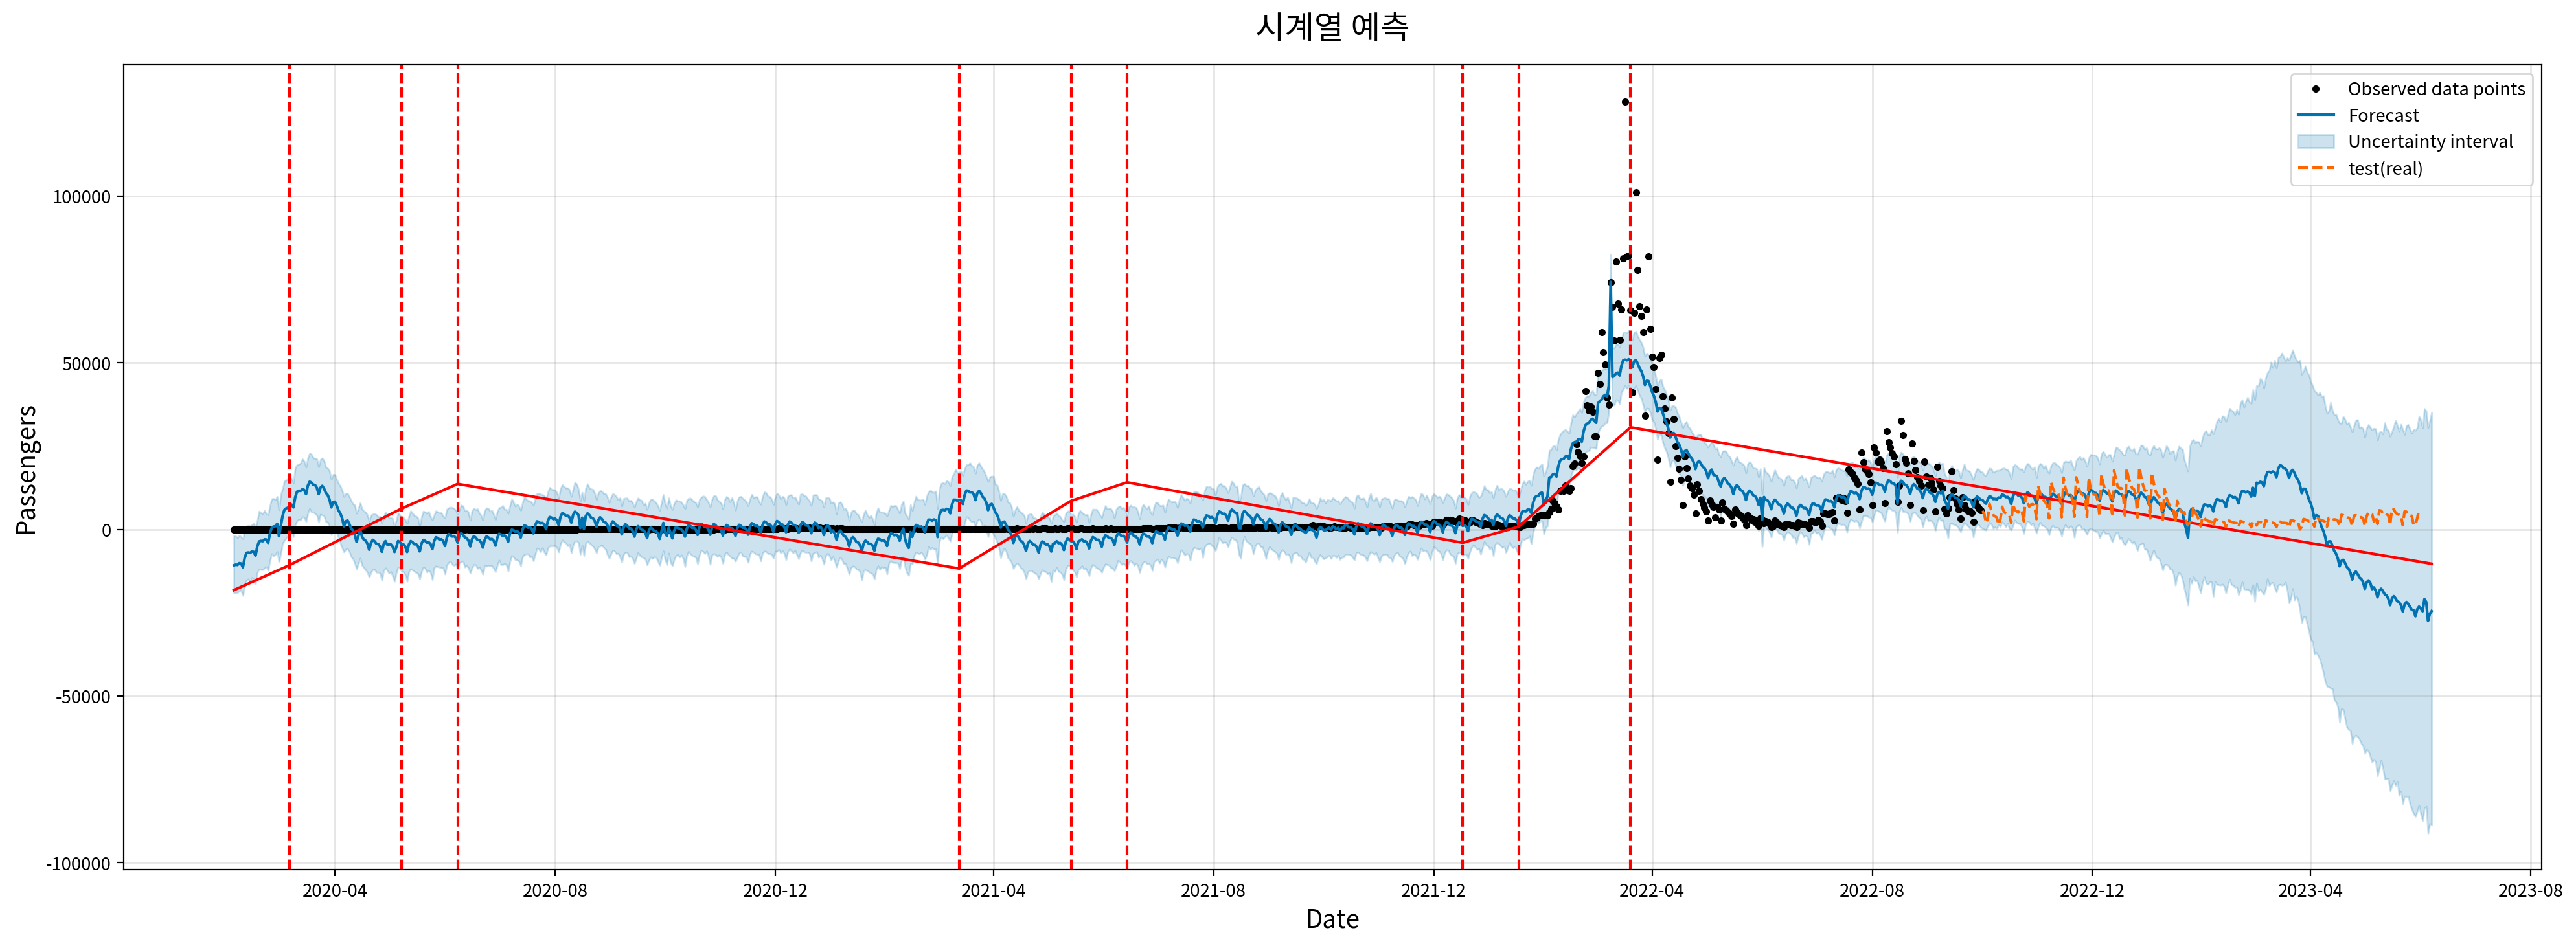

In [17]:
fig = best_model.plot(
    forecast, figsize=(20, 7), xlabel="Date", ylabel="Passengers", uncertainty=True
)
ax = fig.gca()
add_changepoints_to_plot(ax, best_model, forecast)
ax.set_title("시계열 예측")

# 실제 검증 데이터는 직접 추가한다.
sb.lineplot(
    data=test, x="ds", y="y", ax=ax, color="#ff6600", linestyle="--", label="test(real)"
)

plt.show()
plt.close()

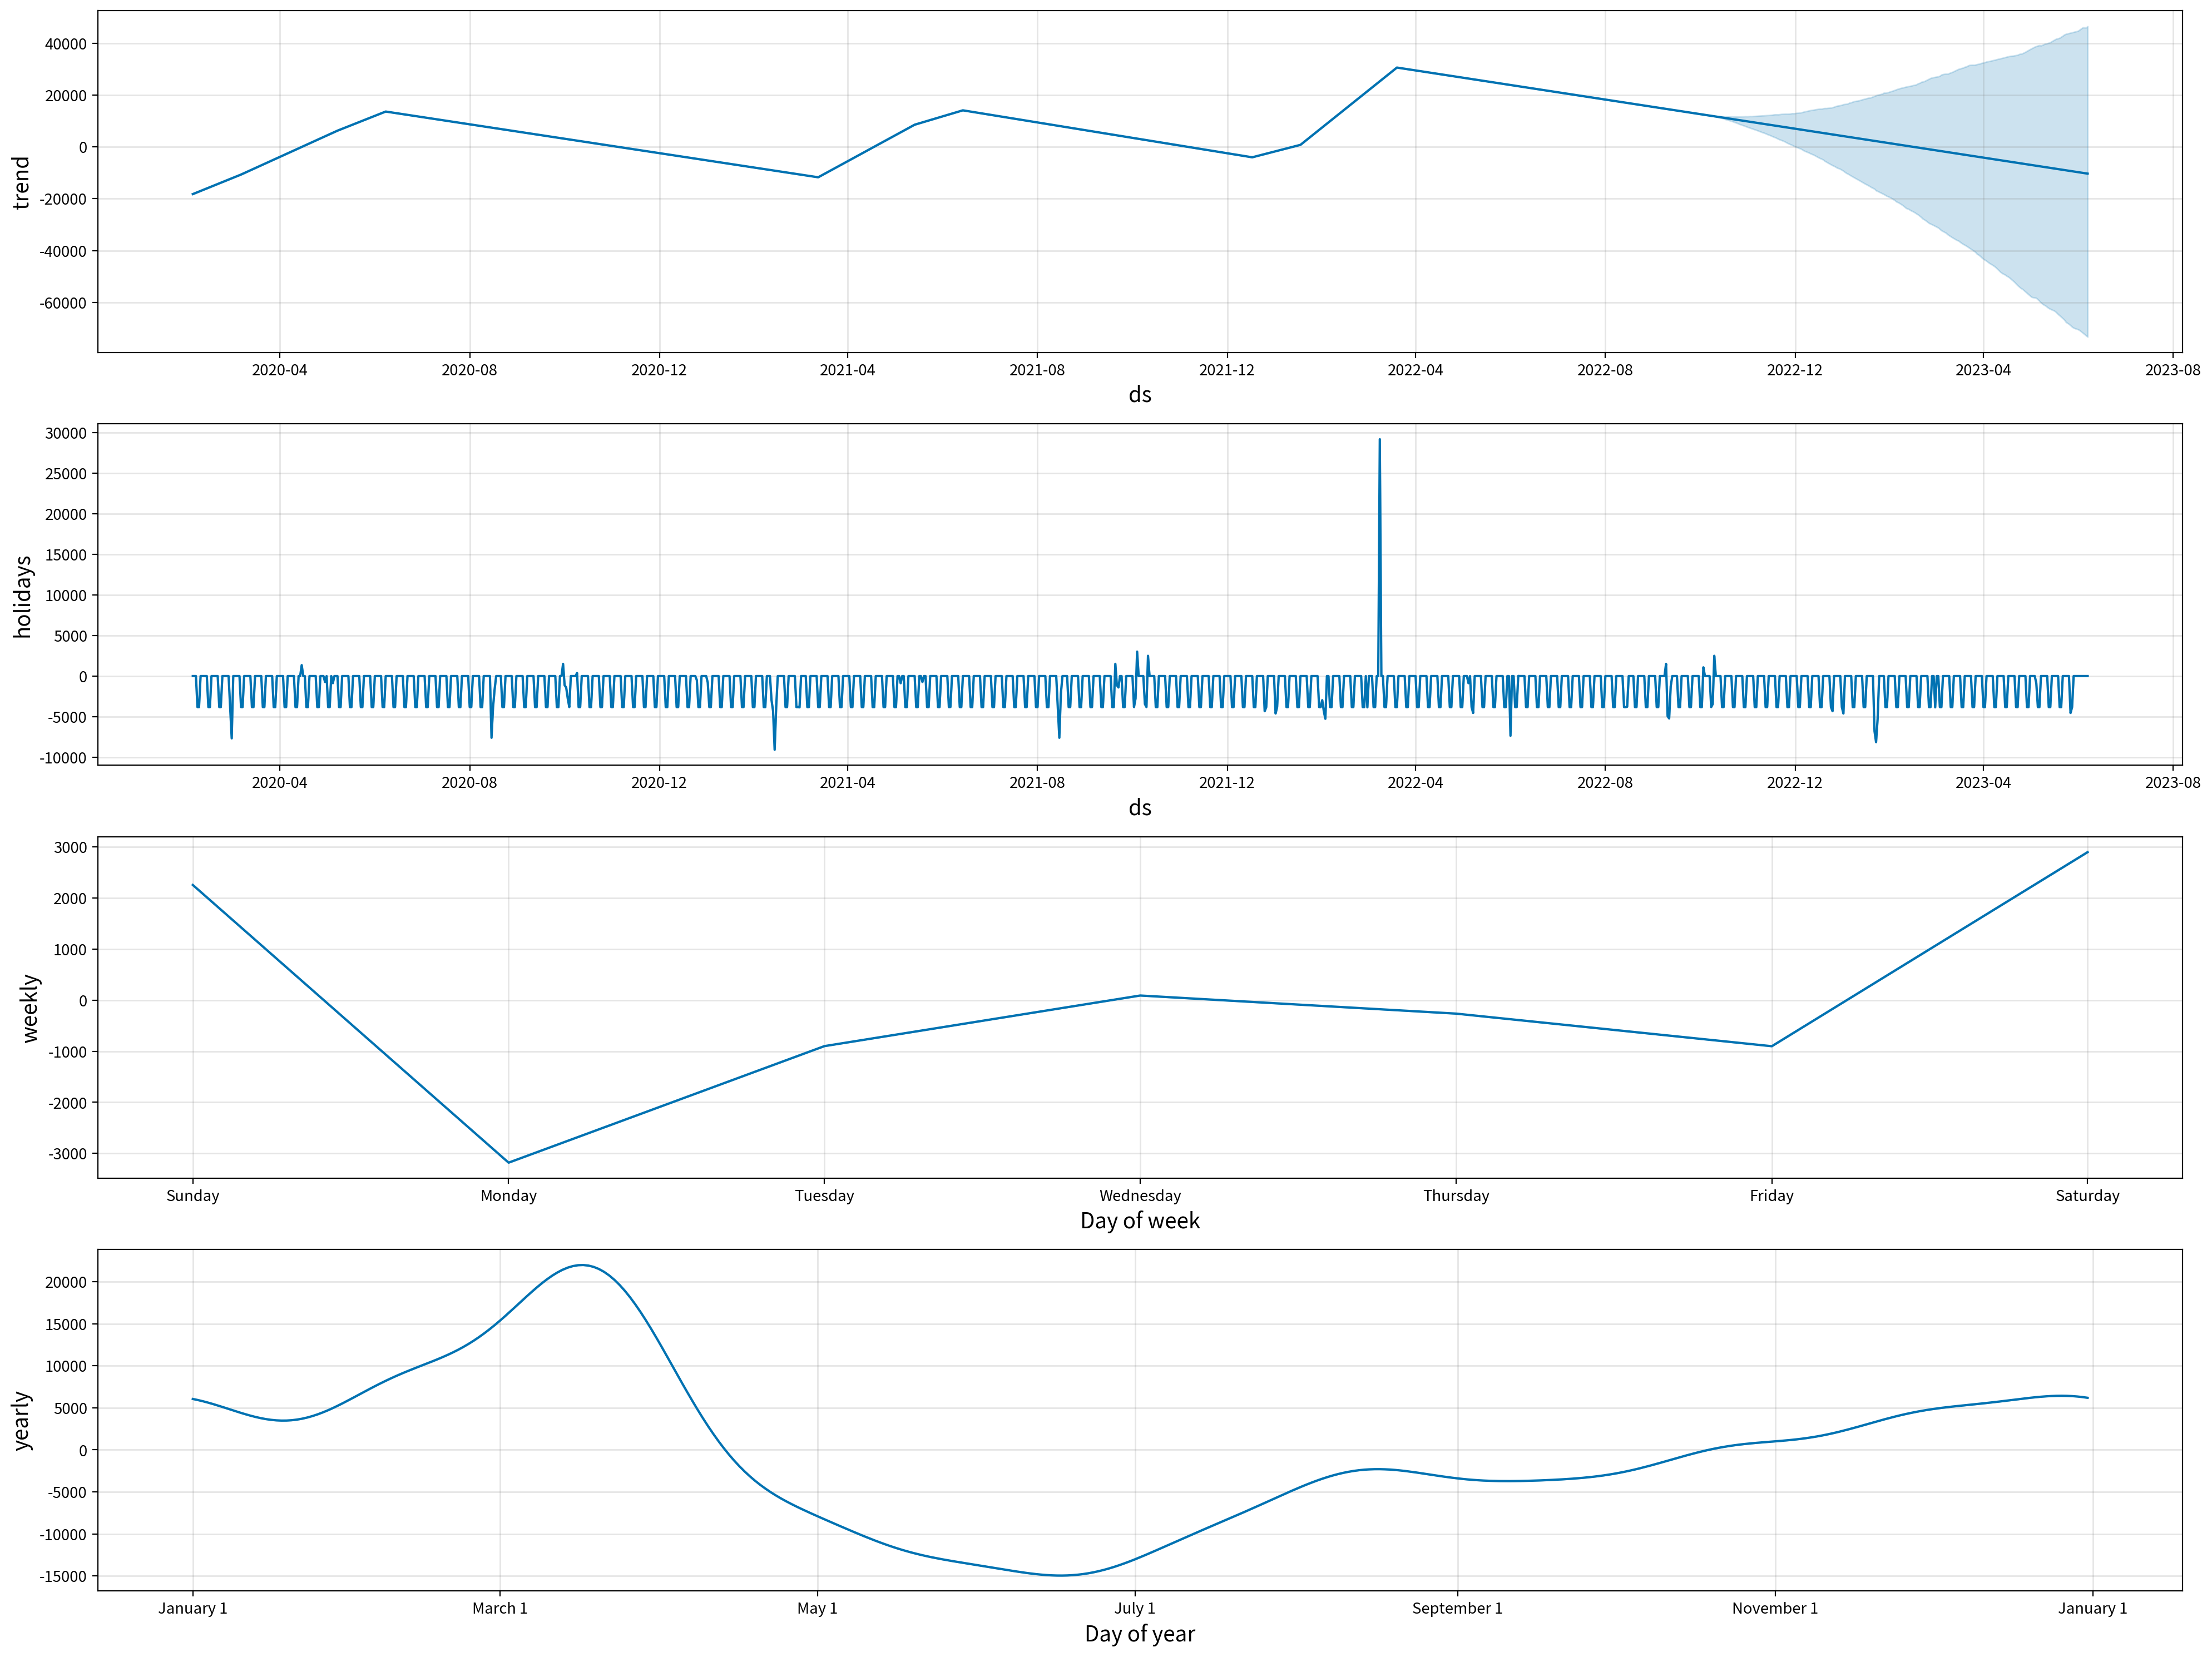

In [18]:
fig = best_model.plot_components(forecast, figsize=(20, 15))
ax = fig.gca()
plt.show()
plt.close()